This ipynb file is made to add perturbations (low pass filter)) to the selected .wav files (with already Wiener filter)

In [1]:
# Standard libraries
from pathlib import Path
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
import shutil

from scipy.io import wavfile
from scipy.signal import wiener, butter, sosfiltfilt


# load data
DATA_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME")

WIENER_INPUT_DIR = DATA_PATH / "wiener_filtered_audio"
LOWPASS_OUTPUT_DIR = DATA_PATH / "wiener_lowpass_perturbations"

LOWPASS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Collect WAV files
wiener_audio_files = []

for root, dirs, files in os.walk(WIENER_INPUT_DIR):
    for file in files:
        if file.endswith(".wav"):
            wiener_audio_files.append(os.path.join(root, file))

print(f"Number of Wiener-filtered audio files: {len(wiener_audio_files)}")


Number of Wiener-filtered audio files: 1941


In [ ]:
def load_wav_file(file_path):
    sample_rate, signal = wavfile.read(file_path)
    return sample_rate, signal


def save_wav_file(file_path, sample_rate, signal):
    signal = np.clip(signal, -32768, 32767)
    signal = signal.astype(np.int16)
    wavfile.write(file_path, sample_rate, signal)


def apply_lowpass_filter(signal, sample_rate, cutoff_hz, filter_order=4):
    """
    Apply a Butterworth low-pass filter to simulate reduced microphone quality.

    Parameters
    signal : np.ndarray
        Input audio signal.
    sample_rate : int
        Sampling rate in Hz.
    cutoff_hz : float
        Low-pass cutoff frequency in Hz.
    filter_order : int
        Order of the Butterworth filter.

    Returns
    filtered_signal : np.ndarray
        Low-pass filtered audio signal.
    """
    signal = signal.astype(np.float32)

    # Safety check
    nyquist = sample_rate / 2
    if cutoff_hz >= nyquist:
        raise ValueError(
            f"cutoff_hz ({cutoff_hz}) must be smaller than Nyquist frequency ({nyquist} Hz)"
        )

    # Design low-pass Butterworth filter 
    sos = butter(
        N=filter_order,
        Wn=cutoff_hz,
        btype="low",
        fs=sample_rate,
        output="sos"
    )

    # Zero-phase filtering
    filtered_signal = sosfiltfilt(sos, signal)

    return filtered_signal


def make_perturbation_output_path(input_path, input_root, output_root, perturbation_name):
    relative_path = os.path.relpath(input_path, input_root)
    output_path = os.path.join(output_root, perturbation_name, relative_path)

    output_dir = os.path.dirname(output_path)
    os.makedirs(output_dir, exist_ok=True)

    return output_path


In [4]:
# Different levels of microphone-quality degradation
perturbations = {
    "low_lowpass": 6000,        
    "medium_lowpass": 4500,     
    "high_lowpass": 3000,       
    "very_high_lowpass": 1500   
}

In [5]:
processed_rows = []

for input_path in wiener_audio_files:
    try:
        sample_rate, signal = load_wav_file(input_path)

        for perturbation_name, cutoff_hz in perturbations.items():
            filtered_signal = apply_lowpass_filter(
                signal=signal,
                sample_rate=sample_rate,
                cutoff_hz=cutoff_hz,
                filter_order=4
            )

            output_path = make_perturbation_output_path(
                input_path=input_path,
                input_root=WIENER_INPUT_DIR,
                output_root=LOWPASS_OUTPUT_DIR,
                perturbation_name=perturbation_name
            )

            save_wav_file(output_path, sample_rate, filtered_signal)

            participant_id = os.path.basename(os.path.dirname(input_path))
            filename = os.path.basename(input_path)

            processed_rows.append({
                "participant_id": participant_id,
                "filename": filename,
                "original_wiener_file_path": input_path,
                "perturbation": perturbation_name,
                "cutoff_hz": cutoff_hz,
                "filter_order": 4,
                "perturbed_file_path": output_path
            })

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

print("Finished processing low-pass filter perturbations.")


Finished processing low-pass filter perturbations.


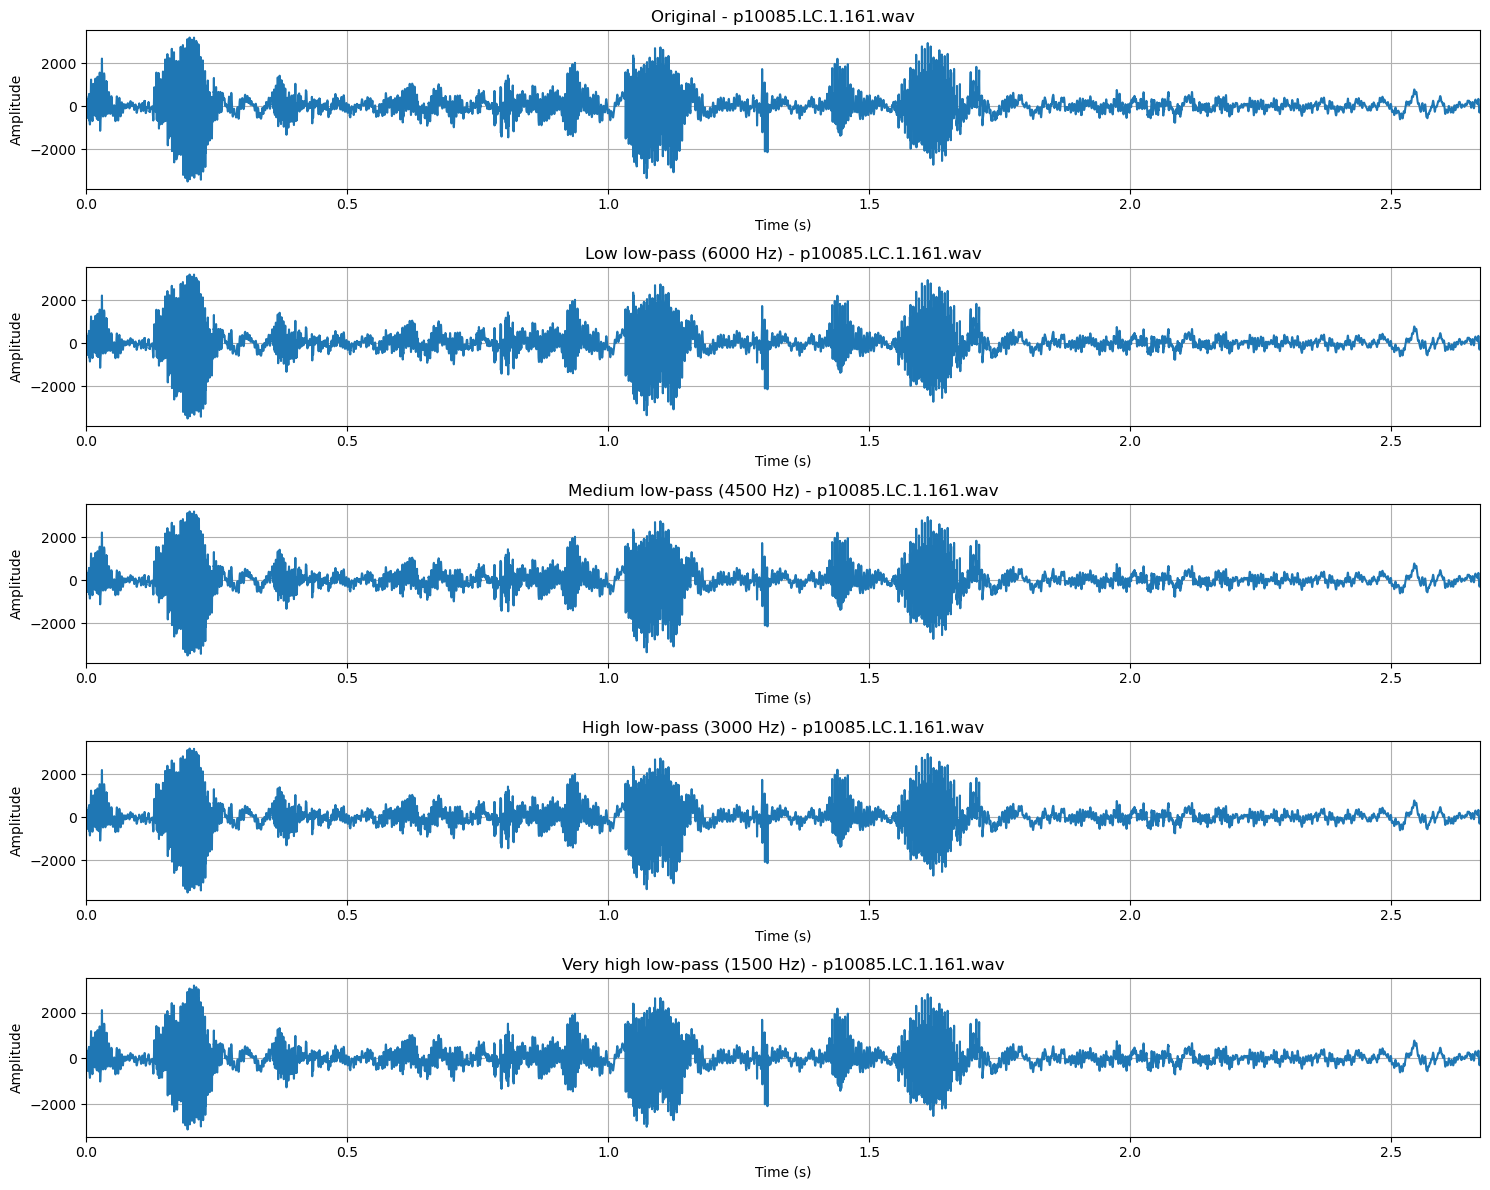

In [6]:
# which participant plot
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(WIENER_INPUT_DIR, participant_id, filename)

lowpass_files = {
    "Original": original_file,
    "Low low-pass (6000 Hz)": os.path.join(LOWPASS_OUTPUT_DIR, "low_lowpass", participant_id, filename),
    "Medium low-pass (4500 Hz)": os.path.join(LOWPASS_OUTPUT_DIR, "medium_lowpass", participant_id, filename),
    "High low-pass (3000 Hz)": os.path.join(LOWPASS_OUTPUT_DIR, "high_lowpass", participant_id, filename),
    "Very high low-pass (1500 Hz)": os.path.join(LOWPASS_OUTPUT_DIR, "very_high_lowpass", participant_id, filename),
}

# Plot
plt.figure(figsize=(15, 12))

for i, (label, file_path) in enumerate(lowpass_files.items(), 1):
    sample_rate, signal = load_wav_file(file_path)
    signal = signal.astype(np.float32)

    time = np.arange(len(signal)) / sample_rate

    plt.subplot(5, 1, i)
    plt.plot(time, signal)
    plt.title(f"{label} - {filename}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, min(3, time[-1]))  # first 3 seconds
    plt.grid(True)

plt.tight_layout()
plt.show()

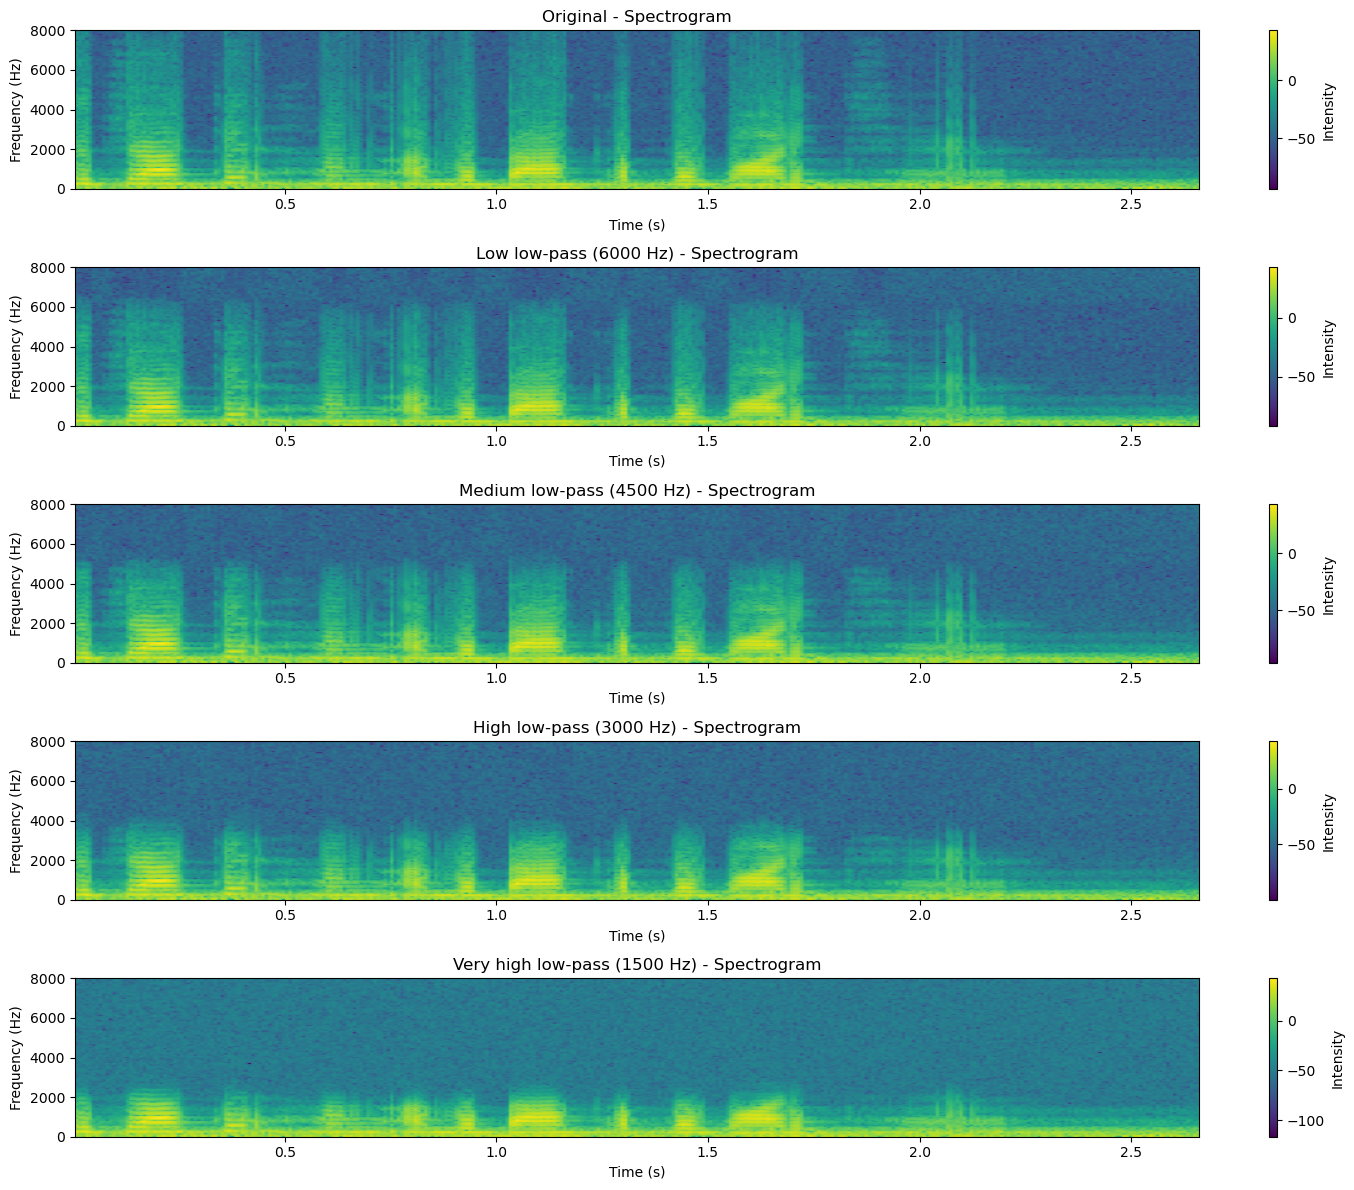

In [7]:
#create a plot in spectogram to visualize the effect of low pass filter 
plt.figure(figsize=(15, 12))

for i, (label, file_path) in enumerate(lowpass_files.items(), 1):
    sample_rate, signal = load_wav_file(file_path)
    signal = signal.astype(np.float32)

    plt.subplot(5, 1, i)
    plt.specgram(signal, Fs=sample_rate)
    plt.title(f"{label} - Spectrogram")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.ylim(0, 8000)  # up to Nyquist
    plt.colorbar(label="Intensity")

plt.tight_layout()
plt.show()